In [ ]:
!python -m pip install numpy==2.2.0
!python -m pip install pandas==2.2.3
!python -m pip install scikit-learn==1.6.0
!python -m pip install matplotlib==3.9.3
!python -m pip install plotly
!python -m pip install seaborn

In [4]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 
from sklearn.datasets import make_blobs 
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

Creating dataset for this project

In [5]:
np.random.seed(0)

With "make_blobs"class, I make random clusters of points.
This can take many inputs, but I use certain ones. <br>

### Input
- n_samples: The total number of points equally divided among clusters. <br>
  Value will be: 5000 <br>
- centres : The number of centres to generate, or the fixed centre locations. <br>
  Value will be: [[4, 4], [-2, -1], [2, -3],[1,1]] <br>
- cluster_std: The standard deviation of the clusters. <br>
  Value will be: 0.9 <br>

### Output

- X: Array of shape [n_samples, n_features]. (Feature Matrix) <br>
  The generated samples. <br>
  samples: points, features: the coordinations of each point
- y: Array of shape [n_samples]. (Response Vector) <br>
  The integer labels for cluster membership of each sample.

In [6]:
X, y = make_blobs(n_samples=5000, centers=[[4,4], [-2, -1], [2, -3], [1, 1]], cluster_std=0.9)

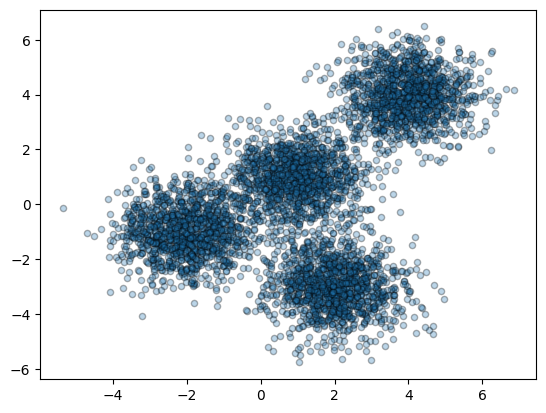

In [7]:
# display generated data
plt.scatter(X[:, 0], X[:, 1], marker='.',alpha=0.3,ec='k',s=80)

### Building k-means clustering
I will have below parameters:
- init <br>
  - initializing centroids <br>
  - its value will be k-means++, which selects initial centers for k-means clustering in a way to speed up convergence
- n_clusters <br>
  - the number of clusters which is also the number of centers
  - its value is 4
- n_init <br>
  - the number of times k-means algorithm will be run with different centroid seeds.
  - the final result will be the best output of those n_init times, which is 12.

Output variable is k_means. 


In [8]:
k_means = KMeans(init = "k-means++", n_clusters = 4, n_init = 12)

# fit the model with feature matrix X
k_means.fit(X)

KMeans(n_clusters=4, n_init=12)

In [10]:
# labels: cluster IDs assigned by K-Means to each sample
# here we have 0, 1, 2, 3
# labels_[i] = c means point i is assigned to cluster c
k_means_labels = k_means.labels_
k_means_labels

array([0, 3, 3, ..., 1, 0, 0])

In [12]:
# getting coordinates of the clusters = the centroids found by K-Means after fitting
# they are the means of the points assigned to each cluster
k_means_cluster_centers = k_means.cluster_centers_
k_means_cluster_centers

array([[-2.03743147, -0.99782524],
       [ 3.97334234,  3.98758687],
       [ 0.96900523,  0.98370298],
       [ 1.99741008, -3.01666822]])

plot the results

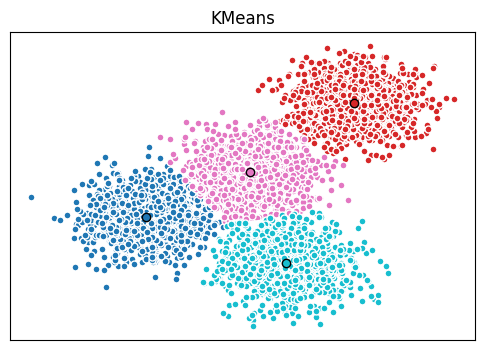

In [14]:
# Initialize the plot with the certain dimensions
fig = plt.figure(figsize=(6, 4))

# Colors uses a color map, which will produce an array of colors based on
# the number of labels there are. I use set(k_means_labels) to get the
# unique labels.
colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_means_labels))))

# Create a plot
ax = fig.add_subplot(1, 1, 1)

# For loop that plots the data points and centroids.
# k will range from 0-3, which will match the possible clusters that each
# data point is in.
for k, col in zip(range(len([[4, 4], [-2, -1], [2, -3], [1, 1]])), colors):

    # Create a list of all data points, where the data points that are 
    # in the cluster (ex. cluster 0) are labeled as true, else they are
    # labeled as false.
    my_members = (k_means_labels == k)

    # Define the centroid, or cluster center.
    cluster_center = k_means_cluster_centers[k]

    # Plots the datapoints with color col.
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.',ms=10)

    # Plots the centroids with specified color, but with a darker outline
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)

# Title of the plot
ax.set_title('KMeans')

# Remove x-axis ticks
ax.set_xticks(())

# Remove y-axis ticks
ax.set_yticks(())

# Show the plot
plt.show()


training with different number of clusters

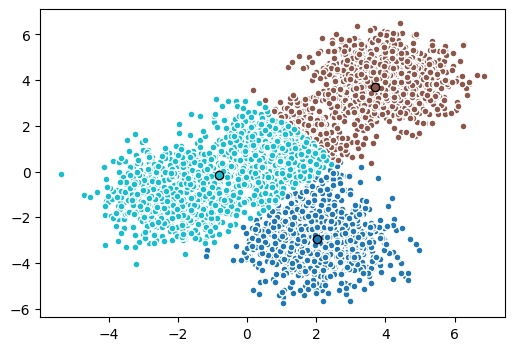

In [ ]:
# k = 3
k_means5 = KMeans(init="k-means++", n_clusters=3, n_init=12)
k_means5.fit(X)
# plot
fig = plt.figure(figsize=(6, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_means5.labels_))))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(len(k_means5.cluster_centers_)), colors):
    my_members = (k_means5.labels_ == k)
    cluster_center = k_means5.cluster_centers_[k]
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.',ms=10)
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)
plt.show()

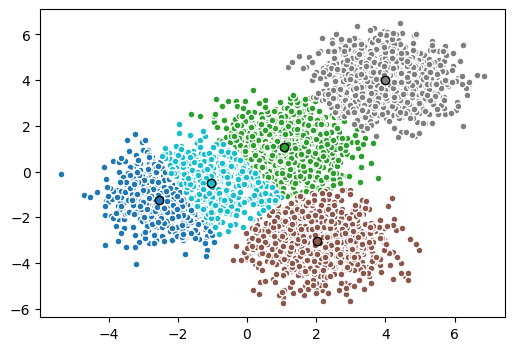

In [17]:
# k = 5
k_means5 = KMeans(init="k-means++", n_clusters=5, n_init=12)
k_means5.fit(X)
fig = plt.figure(figsize=(6, 4))
colors = plt.cm.tab10(np.linspace(0, 1, len(set(k_means5.labels_))))
ax = fig.add_subplot(1, 1, 1)
for k, col in zip(range(len(k_means5.cluster_centers_)), colors):
    my_members = (k_means5.labels_ == k)
    cluster_center = k_means5.cluster_centers_[k]
    ax.plot(X[my_members, 0], X[my_members, 1], 'w', markerfacecolor=col, marker='.',ms=10)
    ax.plot(cluster_center[0], cluster_center[1], 'o', markerfacecolor=col,  markeredgecolor='k', markersize=6)
plt.show()

## Customer segmentation with k-means

My task is to partition a customer base into groups of individuals that have similar characteristics

In [19]:
cust_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/Cust_Segmentation.csv")
cust_df

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
0,1,41,2,6,19,0.124,1.073,0.0,NBA001,6.3
1,2,47,1,26,100,4.582,8.218,0.0,NBA021,12.8
2,3,33,2,10,57,6.111,5.802,1.0,NBA013,20.9
3,4,29,2,4,19,0.681,0.516,0.0,NBA009,6.3
4,5,47,1,31,253,9.308,8.908,0.0,NBA008,7.2
...,...,...,...,...,...,...,...,...,...,...
845,846,27,1,5,26,0.548,1.220,NaN,NBA007,6.8
846,847,28,2,7,34,0.359,2.021,0.0,NBA002,7.0
847,848,25,4,0,18,2.802,3.210,1.0,NBA001,33.4
848,849,32,1,12,28,0.116,0.696,0.0,NBA012,2.9


### pre-processing
I drop "Address" because it is categorical variable. But it could be transformed with one-hot encode

In [20]:
cust_df = cust_df.drop('Address', axis=1)

# dropping NaNs from the dataframe
cust_df = cust_df.dropna()
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 700 entries, 0 to 849
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer Id      700 non-null    int64  
 1   Age              700 non-null    int64  
 2   Edu              700 non-null    int64  
 3   Years Employed   700 non-null    int64  
 4   Income           700 non-null    int64  
 5   Card Debt        700 non-null    float64
 6   Other Debt       700 non-null    float64
 7   Defaulted        700 non-null    float64
 8   DebtIncomeRatio  700 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 54.7 KB


In [22]:
# normalizing over std
# to interpret features with different magnitudes and distributions equally
# having zero mean and standard deviation of one
X = cust_df.values[:,1:] # leaves out `Customer ID`
Clus_dataSet = StandardScaler().fit_transform(X)